# Imports and matplotlib, sklearn practice

In [14]:
import cv2
import numpy as np
import ssl
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.datasets import fetch_openml


In [15]:
# 기본 HTTPS 환경을 '인증서 검증을 하지 않는 상태'로 임시 변경
ssl._create_default_https_context = ssl._create_unverified_context

## Loading sklearn mnist datasets

In [16]:
mnist = fetch_openml('mnist_784', version=1)

In [17]:
mnist.data.shape

(70000, 784)

In [18]:
mnist.target.shape

(70000,)

In [19]:
np.unique(mnist.target)

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

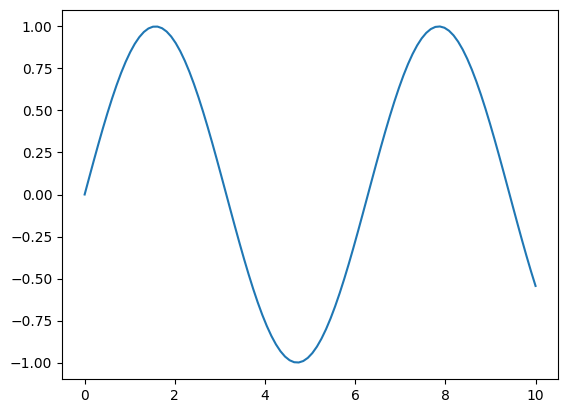

In [20]:
x = np.linspace(0,10,100)
plt.plot(x, np.sin(x))
plt.show()

## Printing digits image with Matplotlib.pyplot

In [21]:
digits = datasets.load_digits()
print(digits.data.shape)
print(digits.images.shape)

(1797, 64)
(1797, 8, 8)


In [22]:
img = digits.images[0, :, :]

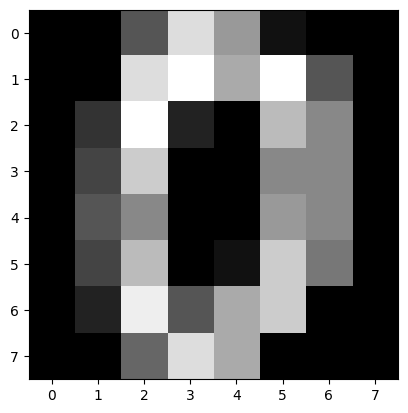

In [23]:
plt.imshow(img, cmap = 'gray')

In [24]:
plt.figure(figsize=(14,4))

<Figure size 1400x400 with 0 Axes>

<Figure size 1400x400 with 0 Axes>

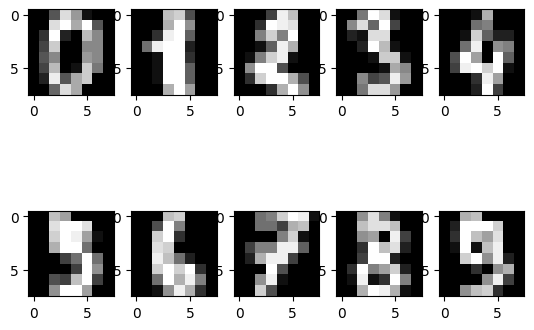

In [25]:
for image_index in range(10):
    subplot_index = image_index+1
    plt.subplot(2,5,subplot_index)
    plt.imshow(digits.images[image_index, :, :], cmap='gray')

# Supervised Learning

In 3DGS we can't say the method uses supervised learning but its training progress is similar to supervised learning so we are going to look at it by using `opencv`

There are 2 types of supervised learning  
`Classification:` It is the task of classifying input data into one of several predefined categories (classes).   
`Regression:` It is a task that involves predicting continuous numerical values.

Shortly *Classification* predicts Categories(Cat & Dog), and *Regression* predicts specific numbers

## How it works

1. Initialize  
2. Set Parameters
3. Train Model
4. Predict new Label
5. Model Scoring

## Practice accuracy, recall, precision score

`accuracy_score:` The proportion of correct predictions a classification model makes out of all predictions.  
`precision_score:` The proportion of actual positives among the cases predicted as positive by the model.  
`recall_score:` The proportion of actual positive cases that the model correctly predicted as positive.

### I. Accuracy Score

Random number initialize, get size = 5 array with 0 and 1

In [26]:
np.random.seed(42)

In [27]:
yTrue=np.random.randint(0,2,size =5)
yTrue

array([0, 1, 0, 0, 0])

Make Prediction

In [28]:
yPred = np.ones(5,dtype=np.int32)
yPred

array([1, 1, 1, 1, 1])

Compute Accuracy

In [29]:
np.sum(yTrue==yPred)/len(yTrue)

0.2

Making it easier and more accurate using sklearn's `metrics`

In [30]:
from sklearn import metrics
metrics.accuracy_score(yTrue,yPred)

0.2

### II. Recall, Precision Score

In [31]:
trulyAPositive = (yTrue ==1)
predictedAPositive = (yPred ==1)
truePositive = np.sum(predictedAPositive*trulyAPositive)
truePositive

1

False Positive

In [32]:
falsePositive = np.sum((yPred ==1)*(yTrue ==0))
falsePositive

4

False Negative

In [33]:
falseNegative = np.sum((yPred == 0 )*(yTrue == 1))
falseNegative

0

True Negative

In [34]:
trueNegative = np.sum((yPred ==0)*(yTrue == 0))
trueNegative

0

Computing Accuracy

In [35]:
accuracy = (truePositive + trueNegative)/len(yTrue)
accuracy

0.2

Computing Precision

In [36]:
precision = truePositive/(truePositive + trueNegative)
precision

1.0

Computing Precision using Scikit-Learn

In [37]:
metrics.precision_score(yTrue,yPred)

0.2

Computing Recall

In [38]:
recall = truePositive/(truePositive + falseNegative)
recall

1.0

In [39]:
metrics.recall_score(yTrue, yPred)

1.0

## Practice Mean Squared Error, Explain Variance Score, r2 Score

In [40]:
x=np.linspace(0,10,100)

y_true: true datas with noise

In [41]:
y_true = np.sin(x)+np.random.rand(x.size)-0.5

y_pred: Let's assume that the model we made worked really well so it predicted perfectly.

In [42]:
y_pred = np.sin(x)

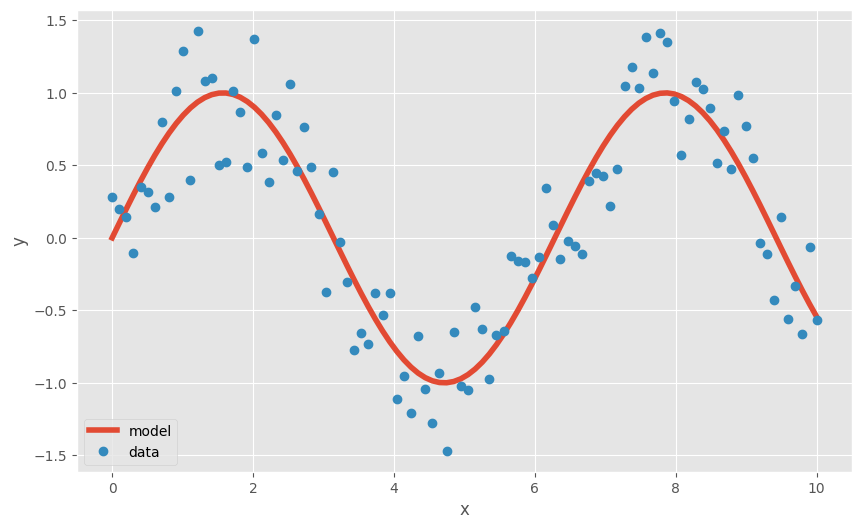

In [43]:
plt.style.use('ggplot')
plt.figure(figsize=(10,6))
plt.plot(x,y_pred,linewidth=4,label='model')
plt.plot(x,y_true,'o',label='data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='lower left')

Computing Mean Squared Error

It involves measuring the squared error between the predicted and actual values ​​and calculating the average.

In [44]:
mse = np.mean((y_true - y_pred)**2)
mse

0.08531839480842378

In [45]:
metrics.mean_squared_error(y_true, y_pred)

0.08531839480842378

Computing Explained Variance Score

It measures the extent to which the model can explain the variance or dispersion of the test data.

In [47]:
fvu = np.var(y_true- y_pred)/np.var(y_true)
fvu

0.163970326266295

In [48]:
fve = 1.0 - fvu
fve

0.836029673733705

In [50]:
metrics.explained_variance_score(y_true, y_pred)

0.836029673733705

Computing $R^2$ score

It is closely related to the explained variance score but uses an unbiased variance estimate.

In [52]:
r2 = 1.0-mse/np.var(y_true)
r2

0.8358169419264746

In [ ]:
metrics.r2_score(y_true, y_pred)

0.8358169419264746

In [54]:
metrics.r2_score(y_true, np.mean(y_true)*np.ones_like(y_true))

0.0